# Evaluation Results Viewer
Reads one or more `eval_results.json` files (produced by `tools/test_tracked.py`) and presents the data as pandas DataFrames.

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

# ── Configuration ────────────────────────────────────────────────────────────
# One path or a list of paths. Each file has the same nested JSON structure.
RESULTS_FILES = [
    "/local/home/nkoefarago/mmpose/benchmark/results/20260610_coco_e2e.json",
    "/local/home/nkoefarago/mmpose/benchmark/results/20260610_coco_topdown.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260610_crowdpose_e2e.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260610_crowdpose_topdown.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260611_ochuman_e2e.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260611_ochuman_topdown.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260615_emdb-mini_e2e.json",
    # "/local/home/nkoefarago/mmpose/benchmark/results/20260615_emdb-mini_topdown.json",
]
# Examples:
# RESULTS_FILES = '/absolute/path/to/eval_results.json'
# RESULTS_FILES = [
#     '/path/to/eval_results.json',
#     '/path/to/other_eval_results.json',
# ]

if isinstance(RESULTS_FILES, str):
    RESULTS_FILES = [RESULTS_FILES]


def load_eval_results(path):
    with open(path) as f:
        raw = json.load(f)
    records = []
    for model_name, variants in raw.items():
        for variant, runs in variants.items():
            for run in runs:
                record = {
                    'model': model_name,
                    'variant': variant,
                    'timestamp': pd.Timestamp(run['timestamp']),
                    'config': run.get('config', ''),
                    'checkpoint': run.get('checkpoint', ''),
                    'source_file': path,
                }
                record.update(run.get('metrics', {}))
                records.append(record)
    return records


# ── Load & flatten ───────────────────────────────────────────────────────────
records = []
for path in RESULTS_FILES:
    if not os.path.isfile(path):
        raise FileNotFoundError(f'Results file not found: {path}')
    records.extend(load_eval_results(path))

df = pd.DataFrame(records)

# Derive all metric columns (everything after the fixed columns)
ID_COLS = ["model", "variant", "timestamp"]
META_COLS = ['config', 'checkpoint', 'source_file']
METRIC_COLS = [c for c in df.columns if c not in (ID_COLS + META_COLS)]

# Fixed plot color per known model family (matplotlib tab20); extend order when adding families.
_MODEL_COLOR_ORDER = [
    'DARK', 'HRFormer', 'HRNet', 'MSPN', 'PCT', 'PETR', 'RSN',
    'RTMPose', 'Sapiens', 'SimCC', 'UDP', 'ViTPose', 'YOLO-Pose', 'YOLO26-Pose',
]
_model_cmap = plt.get_cmap('tab20')
MODEL_COLORS = {m: _model_cmap(i) for i, m in enumerate(_MODEL_COLOR_ORDER)}

print(
    f'Loaded {len(df)} evaluation run(s) from {len(RESULTS_FILES)} file(s) '
    f'| metrics: {METRIC_COLS}'
)

Loaded 109 evaluation run(s) from 2 file(s) | metrics: ['coco/AP', 'coco/AP .5', 'coco/AP .75', 'coco/AP (M)', 'coco/AP (L)', 'coco/AR', 'coco/AR .5', 'coco/AR .75', 'coco/AR (M)', 'coco/AR (L)', 'emdb/MPJVE', 'emdb/MPJAE', 'emdb/bMPJVE', 'emdb/tMPJVE', 'emdb/bMPJAE', 'emdb/tMPJAE', 'perf/e2e/fps', 'perf/e2e/latency_ms_per_batch', 'perf/e2e/latency_ms_per_frame', 'det/bbox_mAP', 'det/bbox_mAP_50', 'det/bbox_mAP_75', 'det/bbox_mAP_s', 'det/bbox_mAP_m', 'det/bbox_mAP_l', 'det/bbox_AR@5', 'det/bbox_AR@10', 'det/bbox_AR@100', 'det/bbox_AR_s@100', 'det/bbox_AR_m@100', 'det/bbox_AR_l@100', 'perf/detector/fps', 'perf/detector/latency_ms_per_batch', 'perf/detector/latency_ms_per_frame', 'perf/keypoint/fps', 'perf/keypoint/latency_ms_per_batch', 'perf/keypoint/latency_ms_per_location']


## All evaluation entries

In [ ]:
display_cols = ID_COLS + METRIC_COLS

all_entries = (
    df[display_cols]
    .sort_values(['model', 'variant', 'timestamp'])
    .reset_index(drop=True)
)

display(
    all_entries.style
    .format({c: '{:.4f}' for c in METRIC_COLS}, na_rep='—')
    .set_caption('All evaluation runs')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

## Latest result per model / variant

In [ ]:
DISPLAY_COLS = ["model", "variant"] + METRIC_COLS

AP_AR_COLS = [c for c in METRIC_COLS if '/AP' in c or '/AR' in c]
OTHER_METRIC_COLS = [c for c in METRIC_COLS if c not in AP_AR_COLS]

fmt = {c: (lambda x: f'{x*100:.1f}' if pd.notna(x) else '—') for c in AP_AR_COLS}
fmt.update({c: '{:.4f}' for c in OTHER_METRIC_COLS})

latest = (
    df.sort_values('timestamp')
    .groupby(['model', 'variant'], sort=False)
    .last()
    .reset_index()
)[DISPLAY_COLS].sort_values(['model', 'variant']).reset_index(drop=True)

display(
    latest.style
    .format(fmt, na_rep='—')
    .set_caption('Latest result per model / variant')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

## Best `coco/AP` run per model

In [ ]:
AP_COL = 'coco/AP'

if AP_COL not in df.columns:
    print(f"Column '{AP_COL}' not found in results. "
          "Available metric columns:", METRIC_COLS)
else:
    best_ap = (
        df.dropna(subset=[AP_COL])
        .sort_values(AP_COL, ascending=False)
        .groupby('model', sort=False)
        .first()
        .reset_index()
    )[ID_COLS + METRIC_COLS].sort_values('model').reset_index(drop=True)

    display(
        best_ap.style
        .format({c: '{:.4f}' for c in METRIC_COLS}, na_rep='—')
        .set_caption(f'Best {AP_COL} run per model (variant + timestamp shown)')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    )

## AP vs e2e FPS

In [ ]:
import hashlib

import matplotlib.pyplot as plt

AP_COL = 'coco/AP'
FPS_COL = 'perf/e2e/fps'
# Set to a positive int to label only the N highest-AP points (0 = no point labels).
ANNOTATE_TOP_N = 0

def color_for_model(model: str):
    """Fixed color for known families; stable hash fallback for others."""
    if model in MODEL_COLORS:
        return MODEL_COLORS[model]
    digest = hashlib.md5(model.encode()).hexdigest()
    n_reserved = len(_MODEL_COLOR_ORDER)
    idx = n_reserved + (int(digest, 16) % (_model_cmap.N - n_reserved))
    return _model_cmap(idx)


missing = [c for c in (AP_COL, FPS_COL) if c not in df.columns]
if missing:
    print(f'Missing columns for plot: {missing}')
    print('Available metric columns:', METRIC_COLS)
else:
    plot_df = (
        df.sort_values('timestamp')
        .groupby(['model', 'variant'], sort=False)
        .last()
        .reset_index()
        .dropna(subset=[AP_COL, FPS_COL])
    )

    if plot_df.empty:
        print(f'No rows with both {AP_COL} and {FPS_COL}.')
    else:
        models = plot_df['model'].unique()

        fig, ax = plt.subplots(figsize=(15, 9))
        for model in models:
            if model == 'Sapiens':
                continue
            sub = plot_df[plot_df['model'] == model]
            ax.scatter(
                sub[FPS_COL],
                sub[AP_COL],
                s=60,
                alpha=0.85,
                color=color_for_model(model),
                label=model,
            )

        if ANNOTATE_TOP_N > 0:
            top = plot_df.nlargest(ANNOTATE_TOP_N, AP_COL)
            for _, row in top.iterrows():
                ax.annotate(
                    f"{row['variant']}",
                    (row[FPS_COL], row[AP_COL]),
                    xytext=(4, 4),
                    textcoords='offset points',
                    fontsize=7,
                    color=color_for_model(row['model']),
                )

        ax.set_xlabel('e2e FPS')
        ax.set_ylabel('coco/AP')
        ax.set_title('Precision vs end-to-end throughput (latest run per model / variant)')
        ax.grid(True, alpha=0.3)
        ax.legend(
            title='model',
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            framealpha=0.9,
        )
        fig.tight_layout()

        # Variant names for each point (no overlap on the chart).
        display(
            plot_df[['model', 'variant', FPS_COL, AP_COL]]
            .sort_values([AP_COL, FPS_COL], ascending=[False, False])
            .reset_index(drop=True)
            .style.format({AP_COL: '{:.3f}', FPS_COL: '{:.1f}'})
            .set_caption('Points on plot (hover-free lookup)')
       
        )
        plt.show()

## AR vs e2e FPS

In [ ]:
import hashlib

import matplotlib.pyplot as plt

AR_COL = 'coco/AR'
FPS_COL = 'perf/e2e/fps'
# Set to a positive int to label only the N highest-AR points (0 = no point labels).
ANNOTATE_TOP_N = 0


def color_for_model(model: str):
    """Fixed color for known families; stable hash fallback for others."""
    if model in MODEL_COLORS:
        return MODEL_COLORS[model]
    digest = hashlib.md5(model.encode()).hexdigest()
    n_reserved = len(_MODEL_COLOR_ORDER)
    idx = n_reserved + (int(digest, 16) % (_model_cmap.N - n_reserved))
    return _model_cmap(idx)


missing = [c for c in (AR_COL, FPS_COL) if c not in df.columns]
if missing:
    print(f'Missing columns for plot: {missing}')
    print('Available metric columns:', METRIC_COLS)
else:
    plot_df = (
        df.sort_values('timestamp')
        .groupby(['model', 'variant'], sort=False)
        .last()
        .reset_index()
        .dropna(subset=[AR_COL, FPS_COL])
    )

    if plot_df.empty:
        print(f'No rows with both {AR_COL} and {FPS_COL}.')
    else:
        models = plot_df['model'].unique()

        fig, ax = plt.subplots(figsize=(15, 9))
        for model in models:
            if model == 'Sapiens':
                continue
            sub = plot_df[plot_df['model'] == model]
            ax.scatter(
                sub[FPS_COL],
                sub[AR_COL],
                s=60,
                alpha=0.85,
                color=color_for_model(model),
                label=model,
            )

        if ANNOTATE_TOP_N > 0:
            top = plot_df.nlargest(ANNOTATE_TOP_N, AR_COL)
            for _, row in top.iterrows():
                ax.annotate(
                    f"{row['variant']}",
                    (row[FPS_COL], row[AR_COL]),
                    xytext=(4, 4),
                    textcoords='offset points',
                    fontsize=7,
                    color=color_for_model(row['model']),
                )

        ax.set_xlabel('e2e FPS')
        ax.set_ylabel('coco/AR')
        ax.set_title('Recall vs end-to-end throughput (latest run per model / variant)')
        ax.grid(True, alpha=0.3)
        ax.legend(
            title='model',
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            framealpha=0.9,
        )
        fig.tight_layout()

        # Variant names for each point (no overlap on the chart).
        display(
            plot_df[['model', 'variant', FPS_COL, AR_COL]]
            .sort_values([AR_COL, FPS_COL], ascending=[False, False])
            .reset_index(drop=True)
            .style.format({AR_COL: '{:.3f}', FPS_COL: '{:.1f}'})
            .set_caption('Points on plot (hover-free lookup)')
       
        )
        plt.show()

## EMDB temporal metrics vs e2e FPS

In [ ]:
import hashlib

import matplotlib.pyplot as plt

FPS_COL = 'perf/e2e/fps'
EMDB_METRIC_COLS = [
    'emdb/bMPJAE',
    'emdb/bMPJVE',
    'emdb/tMPJAE',
    'emdb/tMPJVE',
]
# Set to a positive int to label only the N best (lowest) points per subplot (0 = no labels).
ANNOTATE_TOP_N = 0


def color_for_model(model: str):
    """Fixed color for known families; stable hash fallback for others."""
    if model in MODEL_COLORS:
        return MODEL_COLORS[model]
    digest = hashlib.md5(model.encode()).hexdigest()
    n_reserved = len(_MODEL_COLOR_ORDER)
    idx = n_reserved + (int(digest, 16) % (_model_cmap.N - n_reserved))
    return _model_cmap(idx)


missing = [c for c in EMDB_METRIC_COLS + [FPS_COL] if c not in df.columns]
if missing:
    print(f'Missing columns for plot: {missing}')
    print('Available metric columns:', METRIC_COLS)
else:
    plot_df = (
        df.sort_values('timestamp')
        .groupby(['model', 'variant'], sort=False)
        .last()
        .reset_index()
        .dropna(subset=[FPS_COL])
    )

    if plot_df.empty:
        print(f'No rows with {FPS_COL}.')
    else:
        models = plot_df['model'].unique()

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for ax, metric_col in zip(axes, EMDB_METRIC_COLS):
            sub_df = plot_df.dropna(subset=[metric_col])
            if sub_df.empty:
                ax.set_title(f'{metric_col} (no data)')
                ax.axis('off')
                continue

            for model in models:
                if model == 'Sapiens':
                    continue
                sub = sub_df[sub_df['model'] == model]
                if sub.empty:
                    continue
                ax.scatter(
                    sub[FPS_COL],
                    sub[metric_col],
                    s=60,
                    alpha=0.85,
                    color=color_for_model(model),
                    label=model if metric_col == EMDB_METRIC_COLS[0] else None,
                )

            if ANNOTATE_TOP_N > 0:
                top = sub_df.nsmallest(ANNOTATE_TOP_N, metric_col)
                for _, row in top.iterrows():
                    ax.annotate(
                        f"{row['variant']}",
                        (row[FPS_COL], row[metric_col]),
                        xytext=(4, 4),
                        textcoords='offset points',
                        fontsize=7,
                        color=color_for_model(row['model']),
                    )

            ax.set_xlabel('e2e FPS')
            ax.set_ylabel(metric_col.replace('emdb/', ''))
            ax.set_title(metric_col.replace('emdb/', ''))
            ax.grid(True, alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            title='model',
            bbox_to_anchor=(1.02, 0.98),
            loc='upper left',
            fontsize=8,
            framealpha=0.9,
        )
        fig.suptitle(
            'EMDB temporal metrics vs end-to-end throughput '
            '(latest run per model / variant)',
            y=1.02,
        )
        fig.tight_layout()

        lookup_cols = ['model', 'variant', FPS_COL] + EMDB_METRIC_COLS
        display(
            plot_df[lookup_cols]
            .dropna(subset=EMDB_METRIC_COLS, how='all')
            .sort_values(['model', 'variant'])
            .reset_index(drop=True)
            .style.format(
                {c: '{:.4f}' for c in EMDB_METRIC_COLS} | {FPS_COL: '{:.1f}'}
            )
            .set_caption('Points on plot (hover-free lookup)')
        )
        plt.show()

## bMPJVE vs e2e FPS

,model,variant,perf/e2e/fps,emdb/bMPJVE
0,PCT,huge-rfdetr,6.9,0.0047
1,PCT,huge-rtmdet,6.9,0.0048
2,PCT,large-rfdetr,16.4,0.0050
3,ViTPose,huge-rfdetr,10.0,0.0051
4,PCT,large-rtmdet,16.1,0.0051
5,ViTPose,huge-rtmdet,10.0,0.0052
6,ViTPose,large-rtmdet,14.5,0.0053
7,ViTPose,large-rfdetr,16.1,0.0053
8,PCT,base-rfdetr,23.0,0.0055
9,PCT,base-rtmdet,22.3,0.0056


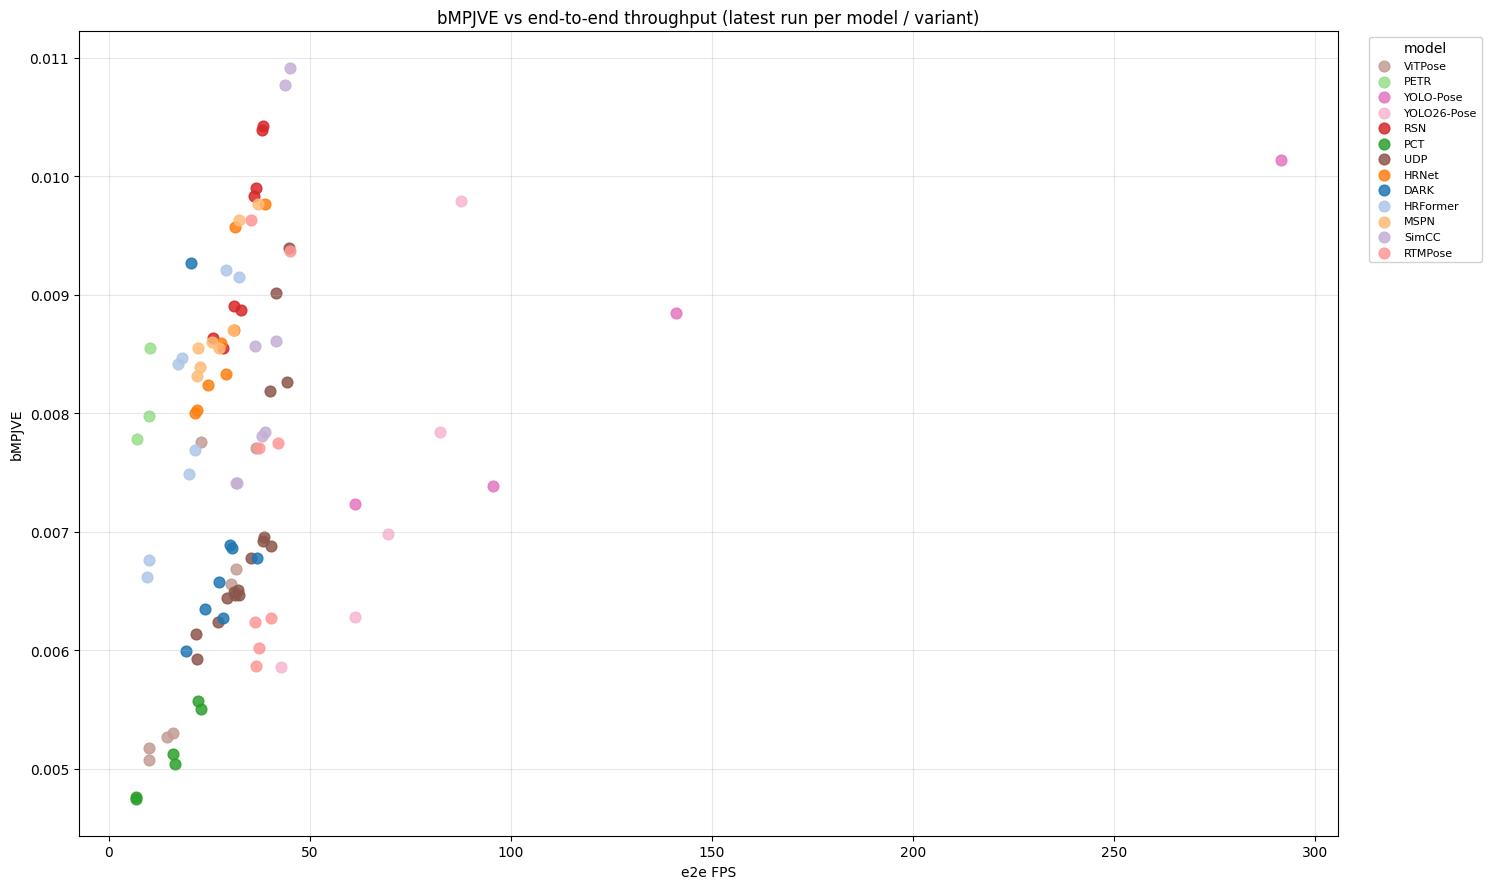

In [4]:
import hashlib

import matplotlib.pyplot as plt

METRIC_COL_NAME = 'emdb/bMPJVE'
FPS_COL = 'perf/e2e/fps'
# Set to a positive int to label only the N best (lowest) points (0 = no point labels).
ANNOTATE_TOP_N = 0


def color_for_model(model: str):
    """Fixed color for known families; stable hash fallback for others."""
    if model in MODEL_COLORS:
        return MODEL_COLORS[model]
    digest = hashlib.md5(model.encode()).hexdigest()
    n_reserved = len(_MODEL_COLOR_ORDER)
    idx = n_reserved + (int(digest, 16) % (_model_cmap.N - n_reserved))
    return _model_cmap(idx)


missing = [c for c in (METRIC_COL_NAME, FPS_COL) if c not in df.columns]
if missing:
    print(f'Missing columns for plot: {missing}')
    print('Available metric columns:', METRIC_COLS)
else:
    plot_df = (
        df.sort_values('timestamp')
        .groupby(['model', 'variant'], sort=False)
        .last()
        .reset_index()
        .dropna(subset=[METRIC_COL_NAME, FPS_COL])
    )

    if plot_df.empty:
        print(f'No rows with both {METRIC_COL_NAME} and {FPS_COL}.')
    else:
        models = plot_df['model'].unique()

        fig, ax = plt.subplots(figsize=(15, 9))
        for model in models:
            if model == 'Sapiens':
                continue
            sub = plot_df[plot_df['model'] == model]
            ax.scatter(
                sub[FPS_COL],
                sub[METRIC_COL_NAME],
                s=60,
                alpha=0.85,
                color=color_for_model(model),
                label=model,
            )

        if ANNOTATE_TOP_N > 0:
            top = plot_df.nsmallest(ANNOTATE_TOP_N, METRIC_COL_NAME)
            for _, row in top.iterrows():
                ax.annotate(
                    f"{row['variant']}",
                    (row[FPS_COL], row[METRIC_COL_NAME]),
                    xytext=(4, 4),
                    textcoords='offset points',
                    fontsize=7,
                    color=color_for_model(row['model']),
                )

        ax.set_xlabel('e2e FPS')
        ax.set_ylabel('bMPJVE')
        ax.set_title('bMPJVE vs end-to-end throughput (latest run per model / variant)')
        ax.grid(True, alpha=0.3)
        ax.legend(
            title='model',
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            framealpha=0.9,
        )
        fig.tight_layout()

        display(
            plot_df[['model', 'variant', FPS_COL, METRIC_COL_NAME]]
            .sort_values([METRIC_COL_NAME, FPS_COL], ascending=[True, False])
            .reset_index(drop=True)
            .style.format({METRIC_COL_NAME: '{:.4f}', FPS_COL: '{:.1f}'})
            .set_caption('Points on plot (hover-free lookup)')
        )
        plt.show()